# 04 Business Momentum Weekly Trends
Sector-level trends + Business-level momentum analysis


## Setup


In [71]:
import warnings
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "notebooks").exists() and (PROJECT_ROOT.parent / "notebooks").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"

# Outputs folder
OUTPUTS_DIR = PROJECT_ROOT / "notebooks" / "outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(NOTEBOOKS_DIR))

from utils.utils import ensure_project_dirs, PROCESSED_DIR, FIGURES_DIR
from utils.visualization import set_plot_style, save_figure
set_plot_style()
ensure_project_dirs()

KPI_PATH = PROJECT_ROOT / "data" / "processed" / "kpi_dataset.csv"


## Load KPI Dataset


In [72]:
# df = pd.read_json(KPI_PATH)
df = pd.read_csv(KPI_PATH)


df["post_date"] = pd.to_datetime(df["post_date"], unit="ms", errors="coerce")

required_columns = [
    "business_name",
    "sector",
    "post_date",
    "engagement",
    "engagement_rate",
    "week",
    "likes_count",
    "comments_count",
    "views_count",
]

missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(
        "This script expects the dataset exported from 00_kpi_engineering. "
        f"Missing columns: {missing_columns}"
    )

df = df.dropna(subset=["business_name", "sector", "week"])


## Helper Function


In [64]:
def classify_trend(growth, threshold=0.10):
    if growth > threshold:
        return "improving"
    elif growth < -threshold:
        return "declining"
    else:
        return "stable"


## Sector Weekly Trends


In [73]:
# This answers:
# Is each sector improving, declining, or stable over time?

sector_weekly = (
    df.groupby(["sector", "week"], as_index=False)
    .agg(
        total_engagement=("engagement", "sum"),
        avg_engagement_rate=("engagement_rate", "mean"),
        total_likes=("likes_count", "sum"),
        total_comments=("comments_count", "sum"),
        total_views=("views_count", "sum"),
        total_posts=("business_name", "size"),
        active_businesses=("business_name", "nunique"),
    )
    .sort_values(["sector", "week"])
)

sector_weekly["sector_growth"] = (
    sector_weekly.groupby("sector")["avg_engagement_rate"]
    .pct_change()
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

sector_weekly["sector_trend_class"] = sector_weekly["sector_growth"].apply(
    lambda x: classify_trend(x, threshold=0.10)
)

# Latest sector status
sector_momentum = (
    sector_weekly.groupby("sector", as_index=False)
    .tail(1)[
        [
            "sector",
            "week",
            "avg_engagement_rate",
            "sector_growth",
            "sector_trend_class",
            "total_posts",
            "active_businesses",
        ]
    ]
    .rename(
        columns={
            "avg_engagement_rate": "latest_sector_engagement_rate",
            "sector_growth": "latest_sector_growth",
            "sector_trend_class": "sector_momentum_class",
        }
    )
)


## Business Weekly Trends


In [74]:
# This answers:
# Is each business improving, declining, stable, or inconsistent?

business_weekly = (
    df.groupby(["sector", "business_name", "week"], as_index=False)
    .agg(
        engagement_rate=("engagement_rate", "mean"),
        engagement=("engagement", "mean"),
        posts_count=("business_name", "size"),
        likes_count=("likes_count", "sum"),
        comments_count=("comments_count", "sum"),
        views_count=("views_count", "sum"),
    )
    .sort_values(["sector", "business_name", "week"])
)

ROLLING_WINDOW = 3
GROWTH_THRESHOLD = 0.10

business_weekly["rolling_engagement_rate"] = (
    business_weekly.groupby("business_name")["engagement_rate"]
    .transform(lambda s: s.rolling(ROLLING_WINDOW, min_periods=1).mean())
)

business_weekly["business_growth"] = (
    business_weekly.groupby("business_name")["rolling_engagement_rate"]
    .pct_change()
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

business_weekly["trend_class"] = business_weekly["business_growth"].apply(
    lambda x: classify_trend(x, threshold=GROWTH_THRESHOLD)
)

# Detect inconsistent businesses
state_counts = (
    business_weekly.groupby("business_name")["trend_class"]
    .nunique()
    .rename("n_states")
)

business_weekly = business_weekly.merge(
    state_counts,
    on="business_name",
    how="left"
)

business_weekly["final_trend_class"] = np.where(
    business_weekly["n_states"] >= 3,
    "inconsistent",
    business_weekly["trend_class"]
)

business_momentum = (
    business_weekly.groupby(["sector", "business_name"], as_index=False)
    .tail(1)[
        [
            "sector",
            "business_name",
            "week",
            "rolling_engagement_rate",
            "business_growth",
            "final_trend_class",
            "posts_count",
        ]
    ]
    .rename(
        columns={
            "rolling_engagement_rate": "latest_rolling_engagement_rate",
            "business_growth": "latest_business_growth",
            "final_trend_class": "business_momentum_class",
        }
    )
)


## Compare Business With Sector


In [75]:
# This gives real business value:
# Is the business performing better or worse than its sector?

comparison = business_momentum.merge(
    sector_momentum[
        [
            "sector",
            "latest_sector_engagement_rate",
            "sector_momentum_class",
        ]
    ],
    on="sector",
    how="left"
)

comparison["performance_vs_sector"] = np.where(
    comparison["latest_rolling_engagement_rate"]
    > comparison["latest_sector_engagement_rate"],
    "above_sector_average",
    "below_sector_average",
)


## Simple Visualizations


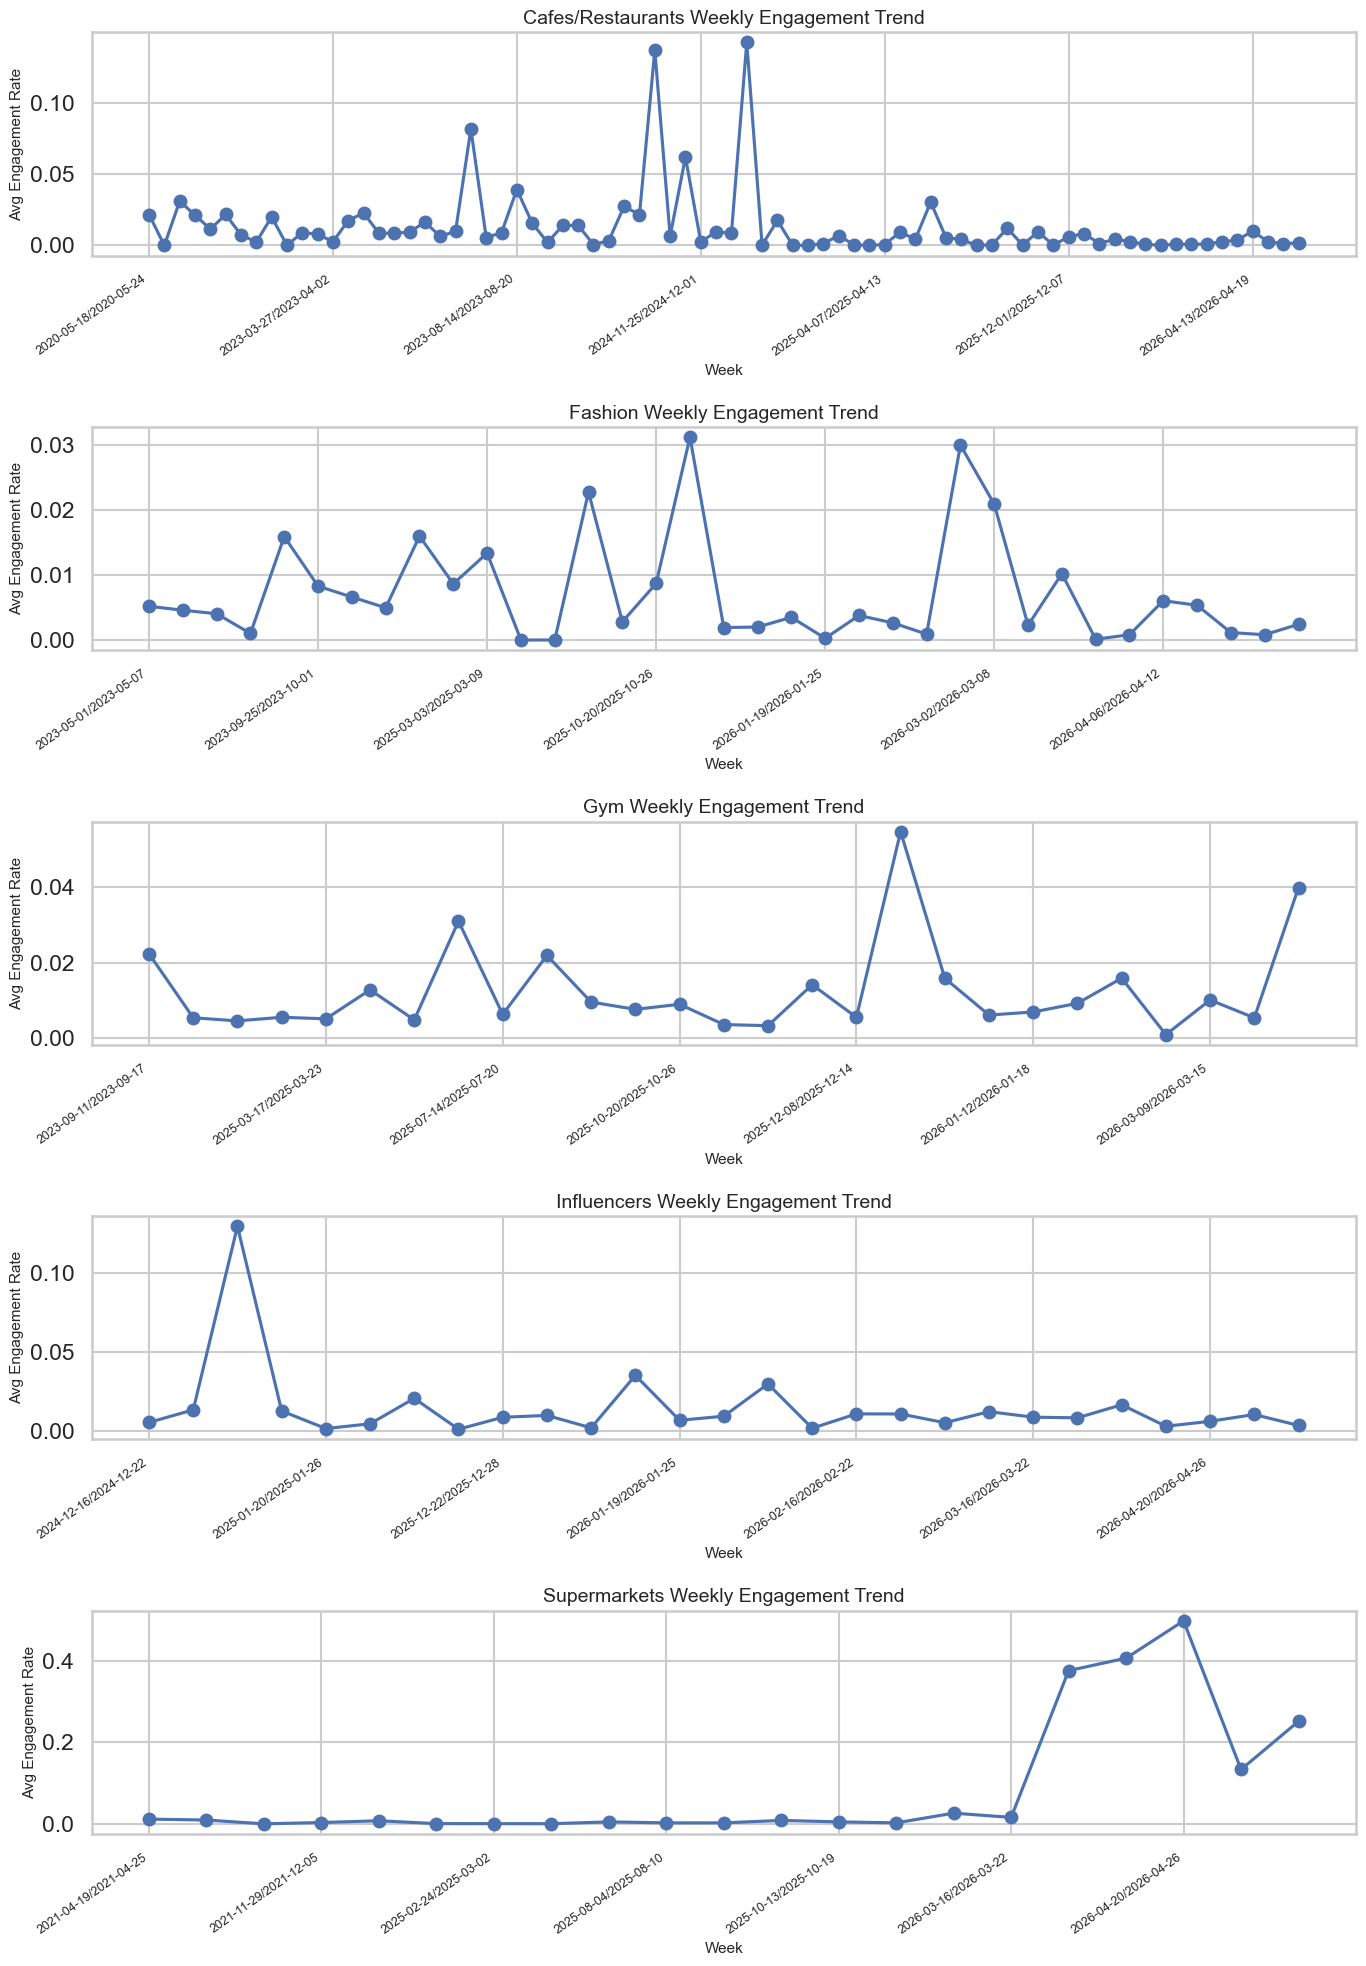

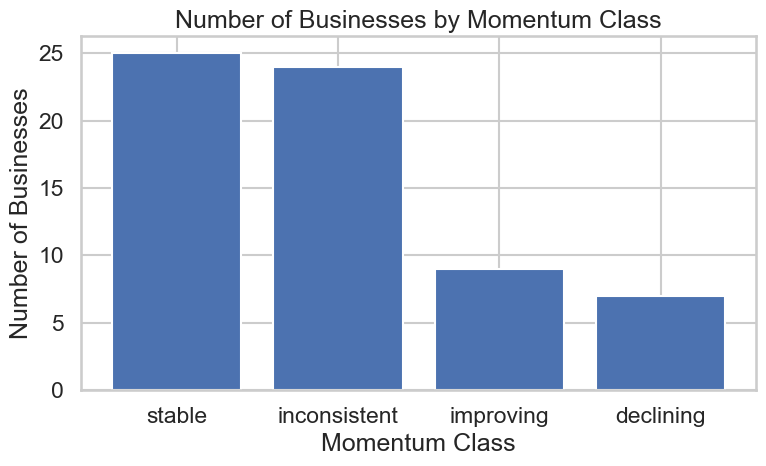

In [76]:
# Plot 1: Sector engagement rate over time
# Plot 1: Separate weekly engagement trend for each sector

sectors = sector_weekly["sector"].unique()
num_sectors = len(sectors)

cols = 1
rows = num_sectors

fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))

if num_sectors == 1:
    axes = [axes]

for i, sector in enumerate(sectors):
    temp = sector_weekly[sector_weekly["sector"] == sector].copy()

    axes[i].plot(
        temp["week"],
        temp["avg_engagement_rate"],
        marker="o"
    )

    axes[i].set_title(f"{sector} Weekly Engagement Trend", fontsize=14)
    axes[i].set_xlabel("Week", fontsize=11)
    axes[i].set_ylabel("Avg Engagement Rate", fontsize=11)

    step = max(1, len(temp) // 6)
    axes[i].set_xticks(range(0, len(temp), step))
    axes[i].set_xticklabels(
        temp["week"].iloc[::step],
        rotation=35,
        ha="right",
        fontsize=9
    )

plt.tight_layout(h_pad=3)

save_figure(
    fig,
    FIGURES_DIR,
    "sector_weekly_engagement_trends_separate.png"
)

plt.show()
# Plot 2: Number of businesses by momentum class
momentum_counts = (
    business_momentum["business_momentum_class"]
    .value_counts()
    .reset_index()
)

momentum_counts.columns = ["momentum_class", "business_count"]

plt.figure(figsize=(8, 5))
plt.bar(
    momentum_counts["momentum_class"],
    momentum_counts["business_count"],
)

plt.title("Number of Businesses by Momentum Class")
plt.xlabel("Momentum Class")
plt.ylabel("Number of Businesses")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "business_momentum_class_counts.png")
plt.show()


## Save Outputs


In [ ]:
sector_weekly.to_csv(
    OUTPUTS_DIR / "sector_weekly_trends.csv",
    index=False,
)

business_momentum.to_csv(
    OUTPUTS_DIR / "business_momentum.csv",
    index=False,
)

comparison.to_csv(
    OUTPUTS_DIR / "business_vs_sector_momentum.csv",
    index=False,
)


## Final Insight


In [70]:
print("Business Momentum Weekly Trends completed successfully.")
print()
print("Generated outputs:")
print("- sector_weekly_trends.csv")
print("- sector_momentum.csv")
print("- business_weekly_trends.csv")
print("- business_momentum.csv")
print("- business_vs_sector_momentum.csv")
print()
print("Main value:")
print("1. Sector trends explain how each sector performs over time.")
print("2. Business momentum explains whether each business is improving, declining, stable, or inconsistent.")
print("3. Business vs sector comparison shows whether a business is above or below its sector average.")


Business Momentum Weekly Trends completed successfully.

Generated outputs:
- sector_weekly_trends.csv
- sector_momentum.csv
- business_weekly_trends.csv
- business_momentum.csv
- business_vs_sector_momentum.csv

Main value:
1. Sector trends explain how each sector performs over time.
2. Business momentum explains whether each business is improving, declining, stable, or inconsistent.
3. Business vs sector comparison shows whether a business is above or below its sector average.
